# Model evaluation
Now I will run the  models I picked check there metrics on the valid dataset and than I will gather my final prediction on the test part of the data

In [12]:
from sklearn.model_selection import train_test_split 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
import xgboost as xgb
import sklearn.metrics as metrics 
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [55]:
tv = pd.read_pickle('tv_show_cleaned.pkl')

In [56]:
x = pd.read_pickle('tv_model')
y = tv['popularity']

In [57]:
x_train,x_temp,y_train,y_temp = train_test_split(x,y,test_size=0.3,random_state=42)

x_test,x_valid,y_test,y_valid = train_test_split(x_temp,y_temp,test_size=0.5,random_state=42)

In [58]:
def regressionMetrics(y, yhat):
    res = {
        'MSE': metrics.mean_squared_error(y, yhat),
        'RMSE': np.sqrt(metrics.mean_squared_error(y, yhat)),
        'MAE': metrics.mean_absolute_error(y, yhat),
        'R2': metrics.r2_score(y, yhat)


    }

    # Check if all values are > -1 to safely apply log
    if np.all(y > -1) and np.all(yhat > -1):
        rmsle = np.sqrt(metrics.mean_squared_log_error(y, yhat))
        res['RMSLE'] = rmsle
    else:
        res['RMSLE'] = 'Not applicable (values ≤ -1)'

    return res

In [ ]:

model_performance = pd.DataFrame()

# The hyper parameters I found:

In [60]:
Random_parameters ={'max_depth': 30, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 8, 'n_estimators': 80}
xg_param ={'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150, 'subsample': 1.0}

## check performance of the valid DB

In [61]:
valid_model = RandomForestRegressor(n_jobs=-1,**Random_parameters)
valid_model.fit(x_train,y_train)
valid_prediction = valid_model.predict(x_valid)
regressionMetrics(y_valid,valid_prediction)


{'MSE': 834.256023437229,
 'RMSE': np.float64(28.88349049954366),
 'MAE': 3.839533254175346,
 'R2': 0.3460299457718363,
 'RMSLE': np.float64(0.48912844267507927)}

Text(0.5, 1.0, 'Actual vs Predicted Popularity')

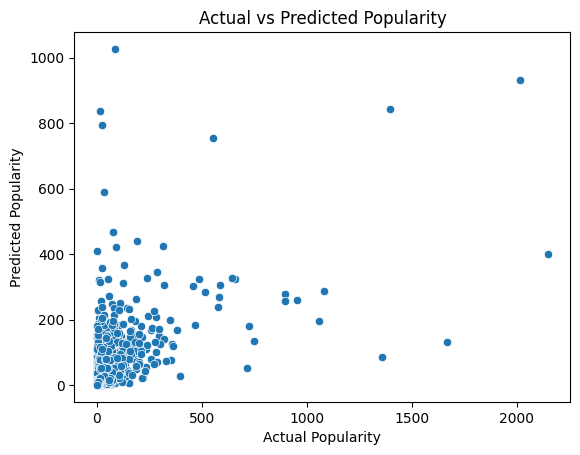

In [62]:
sns.scatterplot(x=y_valid,y=valid_prediction)
plt.xlabel('Actual Popularity')            # X-axis label
plt.ylabel('Predicted Popularity')         # Y-axis label
plt.title('Actual vs Predicted Popularity') # Plot title

# The final  model performance:
I am testing both XGBoost and random forest to see the resault and also the resault of theire average prediction

In [63]:
final_model = RandomForestRegressor(n_jobs=-1,**Random_parameters)
final_model.fit(x_train,y_train)
final_prediction = final_model.predict(x_test)
regressionMetrics(y_test,final_prediction)

{'MSE': 778.2665884255392,
 'RMSE': np.float64(27.89742978171178),
 'MAE': 3.9058609307979246,
 'R2': 0.4565806010612361,
 'RMSLE': np.float64(0.49252756607395815)}

In [64]:
xg_model = xgb.XGBRegressor( **xg_param)
xg_model.fit(x_train,y_train)
xg_model_pred = xg_model.predict(x_test)
xg_model_pred = np.maximum(xg_model_pred,0)
regressionMetrics(y_test,xg_model_pred)



{'MSE': 649.4693151460907,
 'RMSE': np.float64(25.484687856555958),
 'MAE': 4.033132673829835,
 'R2': 0.5465124288839668,
 'RMSLE': np.float64(0.558306399047582)}

In [65]:
pred_metrix= np.array([xg_model_pred,final_prediction])
average_pred = np.mean(pred_metrix, axis=0)
regressionMetrics(y_test,average_pred)

{'MSE': 651.9163352262475,
 'RMSE': np.float64(25.532652334339407),
 'MAE': 3.8588639634960606,
 'R2': 0.5448038136087819,
 'RMSLE': np.float64(0.5068224382906976)}

Text(0.5, 1.0, 'Actual vs Predicted Popularity')

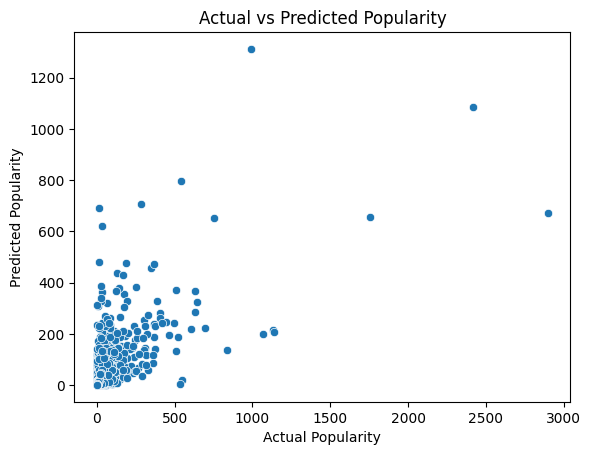

In [72]:
sns.scatterplot(x=y_test,y=final_prediction)
plt.xlabel('Actual Popularity')            # X-axis label
plt.ylabel('Predicted Popularity')         # Y-axis label
plt.title('Actual vs Predicted Popularity') # Plot title

# Using log trasformation deu to highly skewed data

Text(0.5, 1.0, 'Actual vs Predicted Popularity')

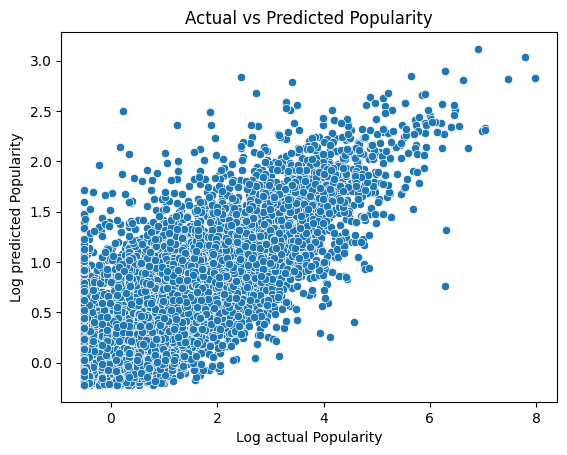

In [67]:
sns.scatterplot(x=np.log(y_test),y=np.log10(final_prediction))
plt.xlabel('Log actual Popularity')            # X-axis label
plt.ylabel('Log predicted Popularity')         # Y-axis label
plt.title('Actual vs Predicted Popularity') # Plot title

In [ ]:
# Make sure both are Series
#actual = pd.Series(y_test).reset_index(drop=True)
#predicted = pd.Series(final_prediction).reset_index(drop=True)

# Convert to quantiles using rank (values from 0 to 1)
#actual_quantiles = actual.rank(pct=True)
#predicted_quantiles = predicted.rank(pct=True)

In [54]:
#sns.scatterplot(x=actual_quantiles, y=predicted_quantiles, alpha=0.5)
#plt.xlabel("Actual Popularity Quantile")
#plt.ylabel("Predicted Popularity Quantile")
#plt.title("Quantile vs Quantile Plot (Q-Q)")
#plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Ideal Prediction')  # Diagonal reference line
#plt.legend()
#plt.grid(True)
#plt.show()


In [68]:
model ={'Model': 'Random forest'}
new_row = pd.DataFrame([{**model,**regressionMetrics(y_test,final_prediction)}])
model_performance = pd.concat([model_performance,new_row],ignore_index=True)
model_performance


,Model,MSE,RMSE,MAE,R2,RMSLE
0,Random forest,778.266588,27.89743,3.905861,0.456581,0.492528


In [69]:
model ={'Model': 'XGBoost'}
new_row = pd.DataFrame([{**model,**regressionMetrics(y_test,xg_model_pred)}])
model_performance = pd.concat([model_performance,new_row],ignore_index=True)
model_performance


,Model,MSE,RMSE,MAE,R2,RMSLE
0,Random forest,778.266588,27.897430,3.905861,0.456581,0.492528
1,XGBoost,649.469315,25.484688,4.033133,0.546512,0.558306


In [70]:

model ={'Model': 'Average prediction'}
new_row = pd.DataFrame([{**model,**regressionMetrics(y_test,average_pred)}])
model_performance = pd.concat([model_performance,new_row],ignore_index=True)
model_performance

,Model,MSE,RMSE,MAE,R2,RMSLE
0,Random forest,778.266588,27.897430,3.905861,0.456581,0.492528
1,XGBoost,649.469315,25.484688,4.033133,0.546512,0.558306
2,Average prediction,651.916335,25.532652,3.858864,0.544804,0.506822


Text(0.5, 1.0, 'Actual vs Predicted Popularity')

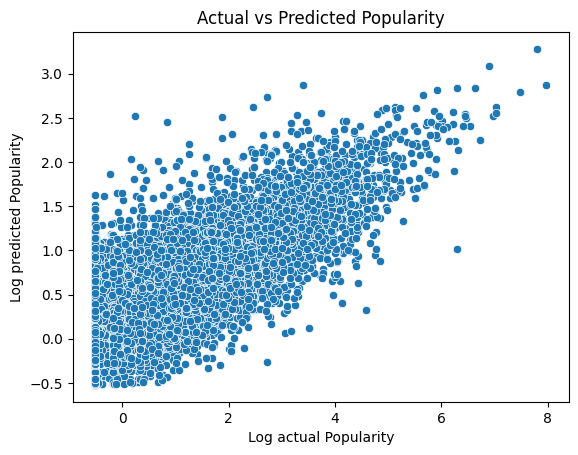

In [71]:
sns.scatterplot(x=np.log(y_test),y=np.log10(average_pred))
plt.xlabel('Log actual Popularity')            # X-axis label
plt.ylabel('Log predicted Popularity')         # Y-axis label
plt.title('Actual vs Predicted Popularity') # Plot title